In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("../dataset/train.csv")
df2 = pd.read_csv("../dataset/test.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
#DNN + RF thì qua file extra dnn nhé
#file này là các combo với DNN còn lại
#build mô hình (nhai lại theo model original tại có F1 cao nhất)
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
#output nhị phân thì ló phải ntn
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
#kệ cái warning nhá ksao đâu

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step
DNN + Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.78      0.95      0.85      1033
           1       0.64      0.24      0.35       374

    accuracy                           0.76      1407
   macro avg       0.71      0.60      0.60      1407
weighted avg       0.74      0.76      0.72      1407



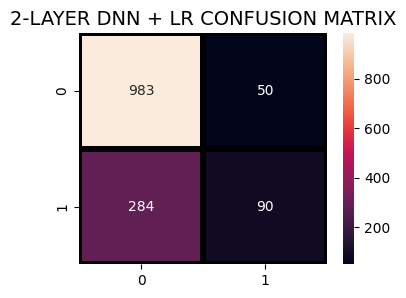

In [5]:
#layer 1: DNN với threshold tối ưu
#quét một khoảng rộng để giữ recall cao (tức là sẽ hơi tham)
y_pred_proba_dnn = model.predict(X_test)
y_pred_dnn = (y_pred_proba_dnn > 0.62745).astype("int32").flatten()
#lọc ra churn candidates
churn_candidates = X_test[y_pred_dnn == 1]

# Layer 2: Logistic Regression lọc lại churn để kéo precision
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(churn_candidates)

#kq
final_predictions_lr = y_pred_dnn.copy()
final_predictions_lr[y_pred_dnn == 1] = y_pred_lr

print("DNN + Logistic Regression Report:")
print(classification_report(y_test, final_predictions_lr))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, final_predictions_lr), annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("2-LAYER DNN + LR CONFUSION MATRIX", fontsize=14)
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step
DNN + XGBoost Report:
              precision    recall  f1-score   support

           0       0.77      0.96      0.86      1033
           1       0.66      0.21      0.32       374

    accuracy                           0.76      1407
   macro avg       0.72      0.58      0.59      1407
weighted avg       0.74      0.76      0.71      1407



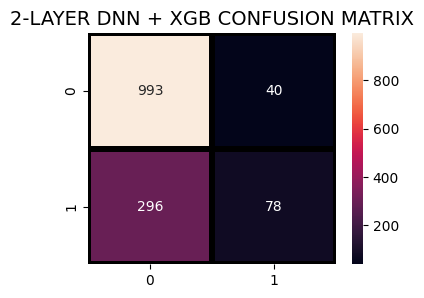

In [8]:
#DNN + XG boost
from xgboost import XGBClassifier

#layer 1: Still DNN with best threshold
y_pred_proba_dnn = model.predict(X_test)
y_pred_dnn = (y_pred_proba_dnn > 0.62745).astype("int32").flatten()
churn_candidates = X_test[y_pred_dnn == 1]

#layer 2: XGBoost
xgb_model = XGBClassifier(n_estimators=500, max_depth=10, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(churn_candidates)

final_predictions_xgb = y_pred_dnn.copy()
final_predictions_xgb[y_pred_dnn == 1] = y_pred_xgb

print("DNN + XGBoost Report:")
print(classification_report(y_test, final_predictions_xgb))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, final_predictions_xgb), annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("2-LAYER DNN + XGB CONFUSION MATRIX", fontsize=14)
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step
DNN + Clustering + RF Report:
              precision    recall  f1-score   support

           0       0.77      0.96      0.86      1033
           1       0.68      0.22      0.33       374

    accuracy                           0.77      1407
   macro avg       0.73      0.59      0.59      1407
weighted avg       0.75      0.77      0.72      1407



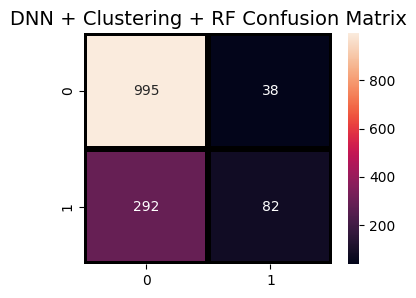

In [9]:
#DNN + clustering + RF
from sklearn.cluster import KMeans

#layer 1: DNN threshold
y_pred_proba_dnn = model.predict(X_test)
y_pred_dnn = (y_pred_proba_dnn > 0.62745).astype("int32").flatten()
# lọc churn candidates
churn_candidates = X_test[y_pred_dnn == 1]

#layer 2: Clustering churn candidates
kmeans = KMeans(n_clusters=3, random_state=42)  # ví dụ chia thành 3 nhóm churn
clusters = kmeans.fit_predict(churn_candidates)
# Thêm cluster ID vào churn_candidates
import pandas as pd
churn_candidates_clustered = pd.DataFrame(churn_candidates)
churn_candidates_clustered["cluster"] = clusters

#layer 3: RF kiểm tra lại
rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
#dự đoán churn trong từng cluster
y_pred_rf = rf_model.predict(churn_candidates)

#kq
final_predictions = y_pred_dnn.copy()
final_predictions[y_pred_dnn == 1] = y_pred_rf

print("DNN + Clustering + RF Report:")
print(classification_report(y_test, final_predictions))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, final_predictions), annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("DNN + Clustering + RF Confusion Matrix", fontsize=14)
plt.show()

In [10]:
data = {
    "Model": [
        "2-layer DNN + RF",
        "2-layer DNN + LR",
        "2-layer DNN + XGB",
        "DNN + Clustering + RF"
    ],
    "Accuracy": [0.77, 0.76, 0.76, 0.77],
    "Precision_churn": [0.69, 0.64, 0.66, 0.68],
    "Recall_churn": [0.52, 0.24, 0.21, 0.22],
    "F1_churn": [0.59, 0.35, 0.32, 0.33]
}
df = pd.DataFrame(data)

print(df.to_string(index=False))

                Model  Accuracy  Precision_churn  Recall_churn  F1_churn
     2-layer DNN + RF      0.77             0.69          0.52      0.59
     2-layer DNN + LR      0.76             0.64          0.24      0.35
    2-layer DNN + XGB      0.76             0.66          0.21      0.32
DNN + Clustering + RF      0.77             0.68          0.22      0.33


In [11]:
#chung kết !!!
data = {
    "Model Group": [
        "Logistic Regression (threshold=0.3)",
        "Decision Tree (threshold=0.3)",
        "KNN (normal)",
        "Random Forest (500 trees + max_depth=10 / top 10 features)",
        "DNN (class weight / new threshold)",
        "Hybrid (DNN + RF)"
    ],
    "Accuracy": [0.77, 0.77, 0.79, 0.78, 0.78, 0.77],
    "Precision_churn": [0.55, 0.55, 0.66, 0.58, 0.58, 0.69],
    "Recall_churn": [0.75, 0.75, 0.42, 0.73, 0.69, 0.52],
    "F1_churn": [0.63, 0.63, 0.51, 0.65, 0.63, 0.59]
}
df = pd.DataFrame(data)

print(df.to_string(index=False))

                                               Model Group  Accuracy  Precision_churn  Recall_churn  F1_churn
                       Logistic Regression (threshold=0.3)      0.77             0.55          0.75      0.63
                             Decision Tree (threshold=0.3)      0.77             0.55          0.75      0.63
                                              KNN (normal)      0.79             0.66          0.42      0.51
Random Forest (500 trees + max_depth=10 / top 10 features)      0.78             0.58          0.73      0.65
                        DNN (class weight / new threshold)      0.78             0.58          0.69      0.63
                                         Hybrid (DNN + RF)      0.77             0.69          0.52      0.59
